In [1]:
import pandas as pd

# 파일 경로 지정
file_path = "taco_full_dataset.parquet"

# 파케이(parquet) 파일 불러오기
df_preview = pd.read_parquet(file_path)

# 상위 3개 행 테이블 형태로 출력 (Jupyter Notebook 환경에 최적화)
display(df_preview.head(3))

,question,solutions,starter_code,input_output,difficulty,raw_tags,name,source,tags,skill_types,url,Expected Auxiliary Space,time_limit,date,picture_num,memory_limit,Expected Time Complexity
0,This is an interactive problem.\n\nIn good old...,[],,"{""inputs"": [""hack\n30\n1 0 1 1 1 1 1 1 1 1 1 1...",HARD,"['interactive', 'binary search', 'geometry', '...",None,codeforces,"[Geometry, Sorting, Constructive algorithms]",['Sorting'],https://codeforces.com/problemset/problem/1063/C,None,2.0 seconds,None,None,256.0 megabytes,None
1,There are $n$ candy boxes in front of Tania. T...,"[""INF = 10000000000.0\nmax_n = 50\nmax_k = 200...",,"{""inputs"": [""5 3 10\n1 2 3 4 5\nRGBRR\n"", ""2 1...",HARD,['dp'],None,codeforces,[Dynamic programming],['Dynamic programming'],https://codeforces.com/problemset/problem/1057/C,None,None,2019-12-31,None,None,None
2,Little Petya likes to play a lot. Most of all ...,[],,"{""inputs"": [""10 10\n5 1 2 4 1 7 3 8 10 8\n0 5 ...",VERY_HARD,"['data structures', 'dsu']",None,codeforces,"[Spanning trees, Data structures]",['Data structures'],https://codeforces.com/problemset/problem/13/E,None,1.0 seconds,None,None,64.0 megabytes,None


[ TACO 데이터셋 요약 통계 ]
1. 전체 행(문제) 개수: 25,443 개
2. count_input 총합: 1,313,317 개
3. count_output 총합: 1,313,317 개
4. count_same이 False인 행 개수: 0 개
----------------------------------------

[ count_input 통계치 ]
 - 평균: 51.62
 - 최소값: 0.0
 - 1사분위수 (25%): 2.0
 - 중위수 (50%): 8.0
 - 3사분위수 (75%): 101.0
 - 최대값: 1440.0


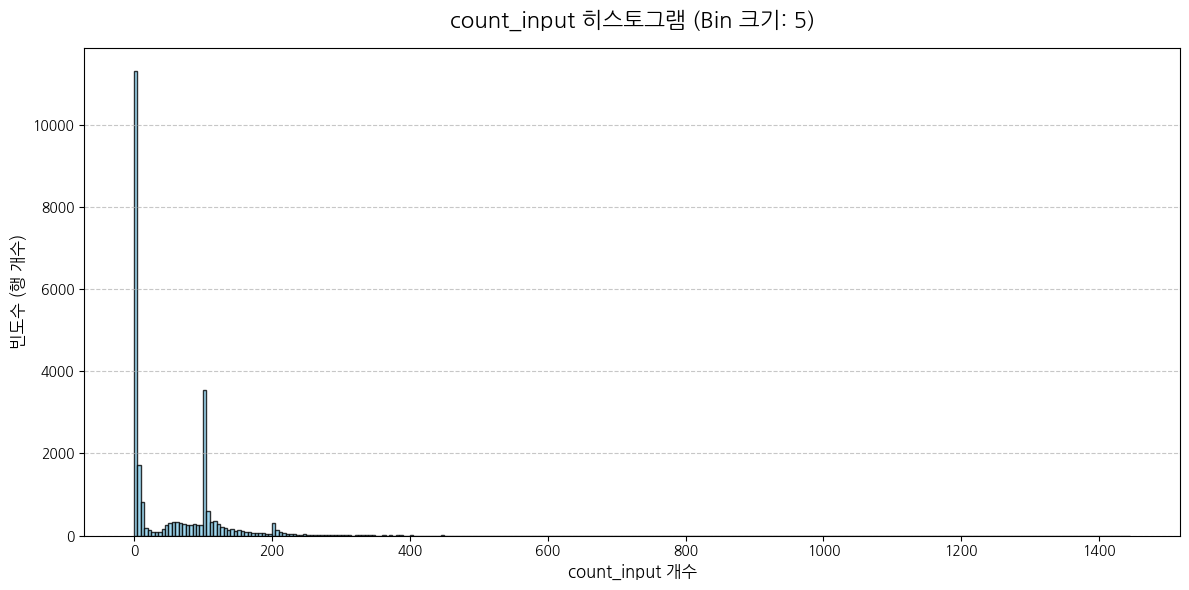

In [1]:
# 1. 나눔고딕 폰트 설치 (Docker Jupyter Linux 환경)
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

import pandas as pd
import ast
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import sys  # <--- 추가된 부분

# 2. 정수-문자열 변환 제한 해제 (에러 해결 핵심 코드)
# TACO 데이터셋에 포함된 수천~수만 자리의 거대한 숫자 파싱을 허용합니다.
sys.set_int_max_str_digits(100000)  # 10만 자리까지 허용 (0으로 설정 시 제한 완전 해제)

# 3. 폰트 설정 및 캐시 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
mpl.rcParams['font.family'] = fe.name
mpl.rcParams['axes.unicode_minus'] = False 

# 4. 데이터 로드
file_path = "taco_full_dataset.parquet"
df = pd.read_parquet(file_path)

# 5. count_input 및 count_output 계산 함수
def count_io(io_data):
    if pd.isna(io_data):
        return 0, 0
    
    # 문자열로 되어있을 경우 dict 형태로 파싱
    if isinstance(io_data, str):
        try:
            io_dict = json.loads(io_data)
        except json.JSONDecodeError:
            try:
                io_dict = ast.literal_eval(io_data)
            except Exception as e:
                return 0, 0
    else:
        io_dict = io_data

    # dict가 정상적일 경우 input/output 개수 측정
    if isinstance(io_dict, dict):
        c_in = len(io_dict.get("inputs", []))
        c_out = len(io_dict.get("outputs", []))
        return c_in, c_out
    
    return 0, 0

# 6. 새로운 열 생성
counts = df['input_output'].apply(count_io)
df['count_input'] = [c[0] for c in counts]
df['count_output'] = [c[1] for c in counts]
df['count_same'] = df['count_input'] == df['count_output']

# 7. 생성한 열을 'input_output' 바로 오른쪽으로 이동
cols = list(df.columns)
for col in ['count_input', 'count_output', 'count_same']:
    cols.remove(col)

io_idx = cols.index('input_output')
cols = cols[:io_idx+1] + ['count_input', 'count_output', 'count_same'] + cols[io_idx+1:]
df = df[cols]

# 8. 전체 통계 수치 계산 및 출력
total_rows = len(df)
sum_count_input = df['count_input'].sum()
sum_count_output = df['count_output'].sum()
false_count_same = (~df['count_same']).sum()

print("=" * 40)
print("[ TACO 데이터셋 요약 통계 ]")
print("=" * 40)
print(f"1. 전체 행(문제) 개수: {total_rows:,} 개")
print(f"2. count_input 총합: {sum_count_input:,} 개")
print(f"3. count_output 총합: {sum_count_output:,} 개")
print(f"4. count_same이 False인 행 개수: {false_count_same:,} 개")
print("-" * 40)

# 9. count_input 상세 통계치 출력
stats = df['count_input'].describe()
print("\n[ count_input 통계치 ]")
print(f" - 평균: {stats['mean']:.2f}")
print(f" - 최소값: {stats['min']}")
print(f" - 1사분위수 (25%): {stats['25%']}")
print(f" - 중위수 (50%): {stats['50%']}")
print(f" - 3사분위수 (75%): {stats['75%']}")
print(f" - 최대값: {stats['max']}")
print("=" * 40)

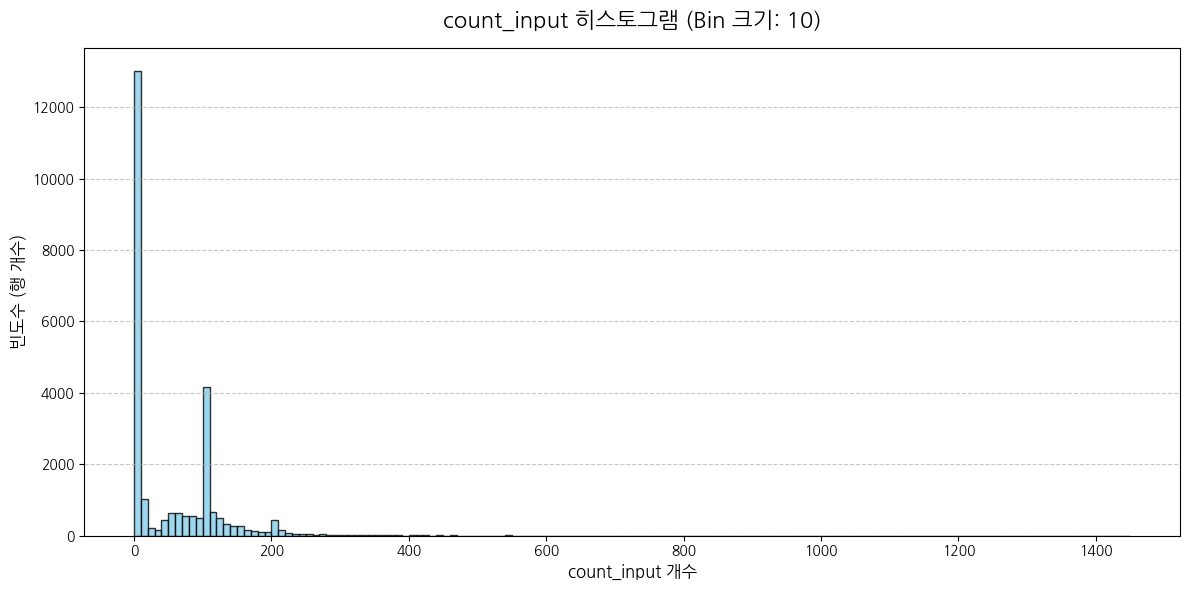

In [2]:
# 10. 히스토그램 시각화 
bin_size = 10

min_val = df['count_input'].min()
max_val = df['count_input'].max()
bins = range(int(min_val), int(max_val) + bin_size + 1, bin_size)

plt.figure(figsize=(12, 6))
plt.hist(df['count_input'], bins=bins, color='skyblue', edgecolor='black', alpha=0.8)

plt.title(f'count_input 히스토그램 (Bin 크기: {bin_size})', fontsize=16, pad=15)
plt.xlabel('count_input 개수', fontsize=12)
plt.ylabel('빈도수 (행 개수)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

[ 필터링된 데이터셋 요약 통계 ]
  * 기준: 50 <= count_input <= 99
1. 필터링된 행 개수: 2,872 개 (원본 대비 11.29%)
2. count_input 총합: 210,362 개
3. count_output 총합: 210,362 개
4. count_same이 False인 행 개수: 0 개
--------------------------------------------------

[ 필터링된 count_input 통계치 ]
 - 평균: 73.25
 - 최소값: 50.0
 - 1사분위수 (25%): 61.0
 - 중위수 (50%): 72.0
 - 3사분위수 (75%): 86.0
 - 최대값: 99.0


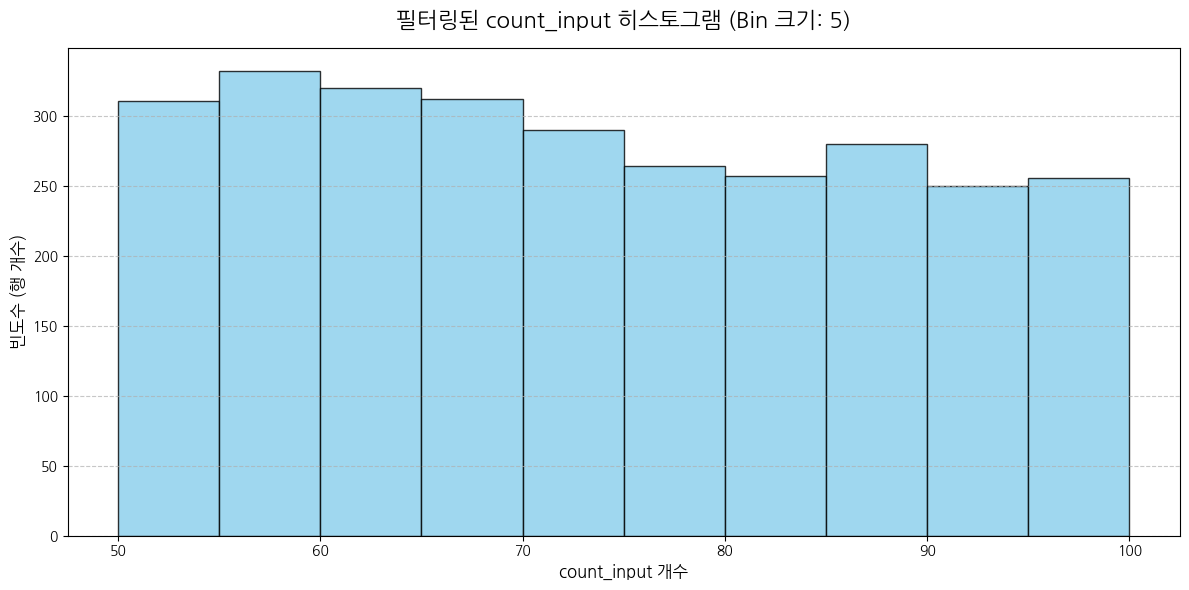


[ 필터링된 데이터 상위 3개 행 ]


,question,solutions,starter_code,input_output,count_input,count_output,count_same,difficulty,raw_tags,name,source,tags,skill_types,url,Expected Auxiliary Space,time_limit,date,picture_num,memory_limit,Expected Time Complexity
1,There are $n$ candy boxes in front of Tania. T...,"[""INF = 10000000000.0\nmax_n = 50\nmax_k = 200...",,"{""inputs"": [""5 3 10\n1 2 3 4 5\nRGBRR\n"", ""2 1...",94,94,True,HARD,['dp'],None,codeforces,[Dynamic programming],['Dynamic programming'],https://codeforces.com/problemset/problem/1057/C,None,None,2019-12-31,None,None,None
2,Little Petya likes to play a lot. Most of all ...,[],,"{""inputs"": [""10 10\n5 1 2 4 1 7 3 8 10 8\n0 5 ...",54,54,True,VERY_HARD,"['data structures', 'dsu']",None,codeforces,"[Spanning trees, Data structures]",['Data structures'],https://codeforces.com/problemset/problem/13/E,None,1.0 seconds,None,None,64.0 megabytes,None
9,There are n cities in Berland. Some pairs of t...,[],,"{""inputs"": [""4 0 1\n3 1 1\n"", ""20 20 40\n4 5\n...",57,57,True,VERY_HARD,"['trees', 'dfs and similar', 'graphs']",None,codeforces,"[Tree algorithms, Graph algorithms, Graph trav...",[],https://codeforces.com/problemset/problem/864/F,None,2.0 seconds,None,None,256.0 megabytes,None


In [1]:
# 1. 나눔고딕 폰트 설치 (Docker Jupyter Linux 환경)
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

import pandas as pd
import ast
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import sys
from IPython.display import display # 표 출력을 위한 모듈

# 2. 정수-문자열 변환 제한 해제 (에러 해결 핵심 코드)
sys.set_int_max_str_digits(100000)

# 3. 폰트 설정 및 캐시 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
mpl.rcParams['font.family'] = fe.name
mpl.rcParams['axes.unicode_minus'] = False 

# 4. 데이터 로드
file_path = "taco_full_dataset.parquet"
df = pd.read_parquet(file_path)

# 5. count_input 및 count_output 계산 함수
def count_io(io_data):
    if pd.isna(io_data):
        return 0, 0
    
    # 문자열로 되어있을 경우 dict 형태로 파싱
    if isinstance(io_data, str):
        try:
            io_dict = json.loads(io_data)
        except json.JSONDecodeError:
            try:
                io_dict = ast.literal_eval(io_data)
            except Exception as e:
                return 0, 0
    else:
        io_dict = io_data

    # dict가 정상적일 경우 input/output 개수 측정
    if isinstance(io_dict, dict):
        c_in = len(io_dict.get("inputs", []))
        c_out = len(io_dict.get("outputs", []))
        return c_in, c_out
    
    return 0, 0

# 6. 새로운 열 생성 및 컬럼 재배치
counts = df['input_output'].apply(count_io)
df['count_input'] = [c[0] for c in counts]
df['count_output'] = [c[1] for c in counts]
df['count_same'] = df['count_input'] == df['count_output']

cols = list(df.columns)
for col in ['count_input', 'count_output', 'count_same']:
    cols.remove(col)

io_idx = cols.index('input_output')
cols = cols[:io_idx+1] + ['count_input', 'count_output', 'count_same'] + cols[io_idx+1:]
df = df[cols]

# ==========================================
# [추가된 부분] 데이터 필터링 변수 설정 및 적용
# ==========================================
min_count_input = 50    # 필터링할 최소 count_input 개수 (원하는 값으로 수정)
max_count_input = 99  # 필터링할 최대 count_input 개수 (원하는 값으로 수정)

# 조건에 맞는 데이터만 필터링
filtered_df = df[(df['count_input'] >= min_count_input) & (df['count_input'] <= max_count_input)].copy()

# 필터링된 데이터가 없을 경우를 대비한 예외 처리
if len(filtered_df) == 0:
    print(f"count_input이 {min_count_input} 이상 {max_count_input} 이하인 데이터가 존재하지 않습니다.")
else:
    # 7. 필터링된 데이터의 통계 수치 계산 및 출력
    total_rows = len(filtered_df)
    sum_count_input = filtered_df['count_input'].sum()
    sum_count_output = filtered_df['count_output'].sum()
    false_count_same = (~filtered_df['count_same']).sum()

    print("=" * 50)
    print(f"[ 필터링된 데이터셋 요약 통계 ]")
    print(f"  * 기준: {min_count_input} <= count_input <= {max_count_input}")
    print("=" * 50)
    print(f"1. 필터링된 행 개수: {total_rows:,} 개 (원본 대비 {(total_rows/len(df))*100:.2f}%)")
    print(f"2. count_input 총합: {sum_count_input:,} 개")
    print(f"3. count_output 총합: {sum_count_output:,} 개")
    print(f"4. count_same이 False인 행 개수: {false_count_same:,} 개")
    print("-" * 50)

    # 8. count_input 상세 통계치 출력
    stats = filtered_df['count_input'].describe()
    print("\n[ 필터링된 count_input 통계치 ]")
    print(f" - 평균: {stats['mean']:.2f}")
    print(f" - 최소값: {stats['min']}")
    print(f" - 1사분위수 (25%): {stats['25%']}")
    print(f" - 중위수 (50%): {stats['50%']}")
    print(f" - 3사분위수 (75%): {stats['75%']}")
    print(f" - 최대값: {stats['max']}")
    print("=" * 50)

    # 9. 히스토그램 시각화 
    bin_size = 5  # bin 크기 조정 변수

    min_val = filtered_df['count_input'].min()
    max_val = filtered_df['count_input'].max()
    
    # max_val과 min_val이 같을 경우 bin 범위 설정 시 발생하는 에러 방지
    if min_val == max_val:
        bins = [min_val - bin_size/2, min_val + bin_size/2]
    else:
        bins = range(int(min_val), int(max_val) + bin_size + 1, bin_size)

    plt.figure(figsize=(12, 6))
    plt.hist(filtered_df['count_input'], bins=bins, color='skyblue', edgecolor='black', alpha=0.8)

    plt.title(f'필터링된 count_input 히스토그램 (Bin 크기: {bin_size})', fontsize=16, pad=15)
    plt.xlabel('count_input 개수', fontsize=12)
    plt.ylabel('빈도수 (행 개수)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # 10. 상위 3개 행 테이블 디스플레이 출력
    print("\n[ 필터링된 데이터 상위 3개 행 ]")
    display(filtered_df.head(3))